# Análisis de Retención y Desempeño de Agentes de Call Center
### Un enfoque de Data Analytics aplicado a la experiencia real en operaciones

Autor: Maikol Marinez
Herramientas: Python (pandas, matplotlib, seaborn, scikit-learn)
Dataset: IBM HR Analytics Employee Attrition & Performance (adaptado)

---

## Contexto

Con 7 años de experiencia en call centers, primero como agente y luego como supervisor, he vivido de cerca uno de los mayores retos operativos de la industria: la alta rotación de personal. Este proyecto nace de esa experiencia — busca aplicar herramientas de análisis de datos para entender, con evidencia cuantitativa, los factores que más influyen en que un agente decida quedarse o irse.

## Objetivo

Identificar los patrones y variables más asociados a la rotación de empleados, y traducir esos hallazgos en recomendaciones accionables para equipos de operaciones y recursos humanos en entornos de call center.

## Preguntas que este análisis busca responder

- ¿Qué porcentaje de la fuerza laboral rota, y en qué perfil se concentra?
- ¿Los turnos extendidos (horas extra) están relacionados con mayor rotación?
- ¿La antigüedad en la empresa reduce el riesgo de que un empleado se vaya?
- ¿Qué variables predicen mejor la rotación: salario, nivel de puesto, distancia al trabajo, tiempo sin ascenso?

## Metodología

Se utilizó el dataset público *IBM HR Analytics Employee Attrition*, adaptando el nombre de sus variables al lenguaje y contexto de operaciones de call center. El análisis sigue un flujo estándar de ciencia de datos: carga y limpieza de datos → análisis exploratorio (EDA) → modelo predictivo (regresión logística) → conclusiones y recomendaciones de negocio.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

print("Todo Listo")


Todo Listo


In [2]:
df= pd.read_csv('Downloads/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape


(1470, 35)

In [4]:
df.columns


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [5]:
df.isnull().sum()


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
# PASO 1: Renombrar columnas clave al lenguaje de call center
df = df.rename(columns={
    'Attrition': 'Rotacion',
    'JobSatisfaction': 'Satisfaccion_Laboral',
    'OverTime': 'Turno_Extendido',
    'MonthlyIncome': 'Salario_Mensual',
    'YearsAtCompany': 'Antiguedad_Anios',
    'DistanceFromHome': 'Distancia_Trabajo',
    'Department': 'Departamento',
    'JobRole': 'Puesto',
    'EnvironmentSatisfaction': 'Satisfaccion_Ambiente',
    'WorkLifeBalance': 'Balance_Vida_Trabajo'
})
# PASO 2: Eliminar columnas que no aportan al análisis (son constantes o solo identificadores)
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])


In [7]:
# PASO 3: Convertir Rotacion de texto (Yes/No) a número (1/0)
df['Rotacion'] = df['Rotacion'].map({'Yes': 1, 'No': 0})



In [10]:

# PASO 4: Confirmar que todo quedó bien
df.head()

,Age,Rotacion,BusinessTravel,DailyRate,Departamento,Distancia_Trabajo,Education,EducationField,Satisfaccion_Ambiente,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,Balance_Vida_Trabajo,Antiguedad_Anios,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


Rotacion
0    83.877551
1    16.122449
Name: proportion, dtype: float64


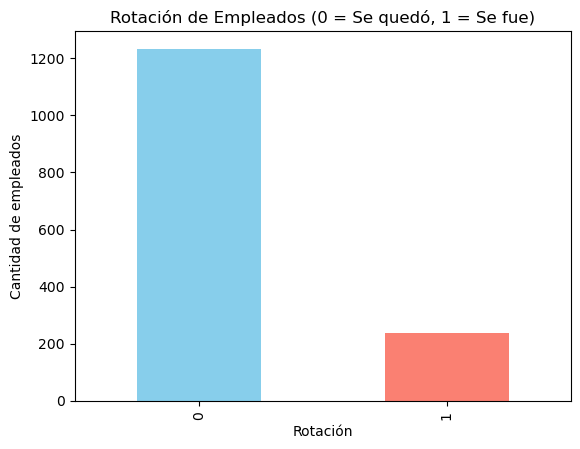

In [11]:
# Porcentaje de rotación general
print(df['Rotacion'].value_counts(normalize=True) * 100)

# Gráfica de barras
df['Rotacion'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Rotación de Empleados (0 = Se quedó, 1 = Se fue)')
plt.xlabel('Rotación')
plt.ylabel('Cantidad de empleados')
plt.show()

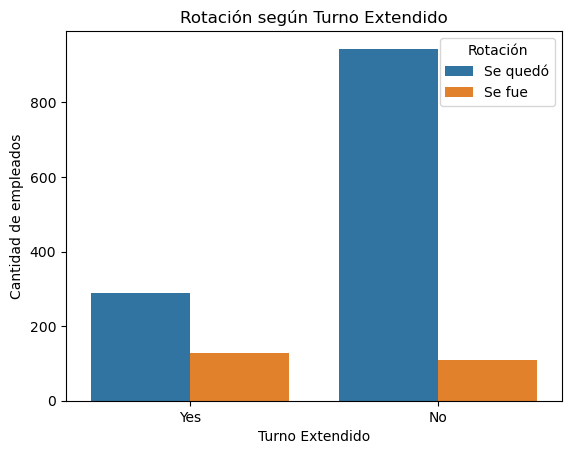

In [12]:
# Rotación según turno extendido
sns.countplot(data=df, x='Turno_Extendido', hue='Rotacion')
plt.title('Rotación según Turno Extendido')
plt.xlabel('Turno Extendido')
plt.ylabel('Cantidad de empleados')
plt.legend(title='Rotación', labels=['Se quedó', 'Se fue'])
plt.show()

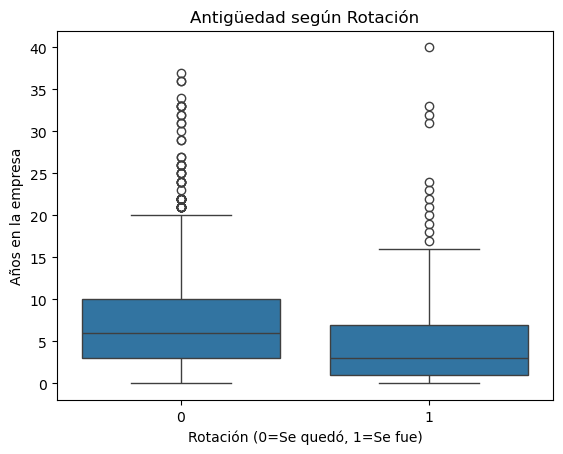

In [13]:
# Antigüedad vs rotación (boxplot)
sns.boxplot(data=df, x='Rotacion', y='Antiguedad_Anios')
plt.title('Antigüedad según Rotación')
plt.xlabel('Rotación (0=Se quedó, 1=Se fue)')
plt.ylabel('Años en la empresa')
plt.show()

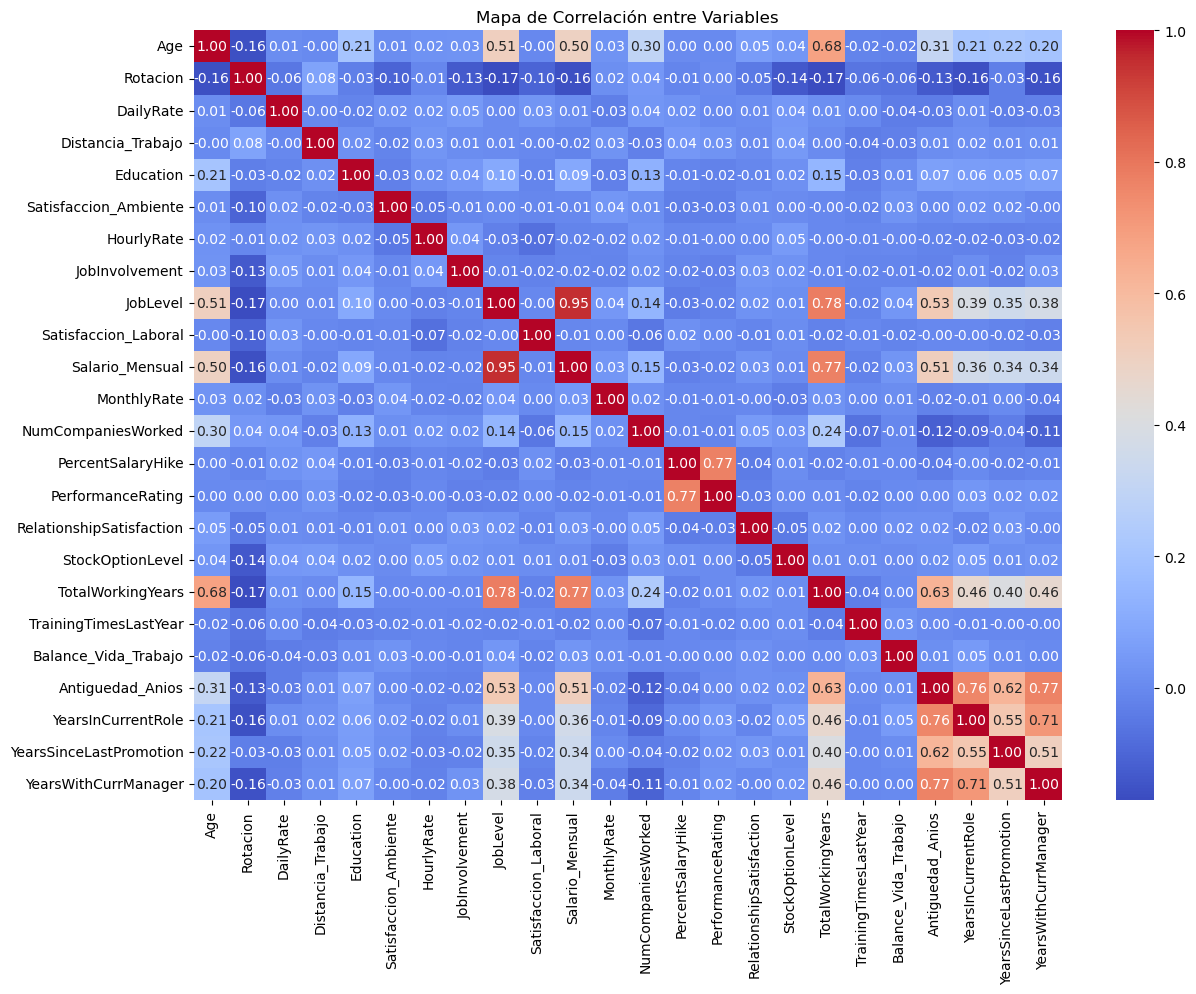

In [14]:
# Mapa de correlación entre variables numéricas
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Correlación entre Variables')
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

# Estandarizar las variables (ponerlas en la misma escala)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Volver a entrenar el modelo con datos escalados
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_scaled, y_train)

predicciones = modelo.predict(X_test_scaled)
print("Precisión del modelo (escalado):", accuracy_score(y_test, predicciones))

importancia = pd.Series(modelo.coef_[0], index=X.columns).sort_values(ascending=False)
print(importancia)

Precisión del modelo (escalado): 0.8843537414965986
Antiguedad_Anios            0.537834
YearsSinceLastPromotion     0.429118
NumCompaniesWorked          0.398405
Distancia_Trabajo           0.256371
PerformanceRating           0.059681
MonthlyRate                 0.045819
Education                   0.044599
HourlyRate                  0.007926
DailyRate                  -0.056175
RelationshipSatisfaction   -0.086703
PercentSalaryHike          -0.131489
TrainingTimesLastYear      -0.161241
Balance_Vida_Trabajo       -0.171589
JobLevel                   -0.210633
Salario_Mensual            -0.219714
Age                        -0.239343
Satisfaccion_Ambiente      -0.272256
JobInvolvement             -0.312771
Satisfaccion_Laboral       -0.325682
TotalWorkingYears          -0.346821
YearsWithCurrManager       -0.395892
StockOptionLevel           -0.498192
YearsInCurrentRole         -0.590404
dtype: float64


## Conclusiones y Recomendaciones

### Resumen del hallazgo principal
El análisis, basado en una muestra de 1,470 empleados, encontró una tasa de rotación general del 16.1%. Mediante análisis exploratorio y un modelo de regresión logística (con una precisión del 88.4%), se identificaron patrones consistentes que apuntan a que la rotación no es aleatoria, sino que se concentra en perfiles específicos: empleados con poca antigüedad, turnos extendidos y pocas oportunidades de crecimiento reciente.

### Insights clave

1. Turno extendido dispara la rotación. Los empleados con horas extra (turno extendido) muestran una proporción de rotación notablemente más alta que quienes no las tienen. Esto es consistente con la fatiga operativa característica de entornos de alta exigencia como los call centers.

2. La rotación es un problema de los primeros años. La antigüedad mediana de quienes se van (~3 años) es considerablemente menor que la de quienes se quedan (~5 años). El riesgo de fuga es mayor en la etapa de adaptación e integración del empleado, no después de consolidarse en su rol.

3. Estancamiento profesional pesa más que el salario. Variables como YearsSinceLastPromotion (tiempo sin ascenso) y NumCompaniesWorked (historial de rotación previa) tuvieron mayor peso predictivo que el salario mensual. Esto sugiere que la percepción de progreso importa tanto o más que la compensación económica.

4. La distancia al trabajo también influye. A mayor distancia entre el hogar y el centro de trabajo, mayor la probabilidad de rotación — un factor relevante para decisiones de horarios híbridos o remotos.

5. Limitación técnica identificada: el modelo mostró multicolinealidad entre las variables relacionadas con antigüedad (Antiguedad_Anios, YearsInCurrentRole, TotalWorkingYears), lo que afecta la interpretación aislada de sus coeficientes. Para el análisis de causalidad de antigüedad se priorizó la evidencia del análisis exploratorio (boxplot) sobre el coeficiente del modelo.

### Recomendaciones accionables

- Priorizar la retención en los primeros 12-24 meses, con seguimiento cercano de supervisor a nuevos ingresos (mentoría, check-ins frecuentes).
- Rotar o limitar la exposición a turnos extendidos, especialmente en agentes de baja antigüedad, para reducir el desgaste temprano.
- Crear rutas de crecimiento visibles a corto plazo (ascensos, cambios de rol, certificaciones internas) que no dependan exclusivamente de años de servicio.
- Evaluar políticas de flexibilidad de horario o modalidad remota/híbrida para agentes con mayor distancia al centro de trabajo.

### Limitaciones del análisis
Este proyecto utilizó un dataset adaptado de IBM (no datos reales de un call center), por lo que los hallazgos deben tomarse como hipótesis a validar con datos operativos reales. Se recomienda replicar este análisis con variables específicas de la industria como AHT, CSAT y ausentismo para mayor precisión.

---
*Este análisis fue desarrollado combinando herramientas de análisis de datos en Python con experiencia práctica de 7 años en operaciones de call center, en roles de agente y supervisor.*

### Nota
Durante mi desempeño como supervisor, tuve muchas rotaciones de parte de agentes que eran estudiantes activos y, en su gran mayoría, fueron a causa del cambio de horario en la universidad. Otros simplemente no podían con la carga académica y el estrés laboral. 